### Project title:
# Customer_Personality_Analysis- Exploratory Data Analysis

### Phase 1: Dataset Selection and Problem Definition

#### Dataset Source: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

#### About the dataset:
#### This dataset contains 29 orginal fetures describing customer demographic information, purchasing behavior,campaign responses, and spending habits of customers. The objective is to analyze customer characteristics and identify patterns that can help businesses improve marketing strategies.


### Understanding the Dataset(Data Dictionary)
### Important columns:

| Column              | Meaning                       |
| ------------------- | ----------------------------- |
| ID                  | Customer ID                   |
| Year_Birth          | Birth year                    |
| Education           | Education level               |
| Marital_Status      | Marital status                |
| Income              | Annual income                 |
| Kidhome             | Number of kids                |
| Teenhome            | Number of teenagers           |
| Dt_Customer         | Customer enrollment date      |
| Recency             | Days since last purchase      |
| MntWines            | Amount spent on wine          |
| MntFruits           | Amount spent on fruits        |
| MntMeatProducts     | Amount spent on meat          |
| MntFishProducts     | Amount spent on fish          |
| MntSweetProducts    | Amount spent on sweets        |
| MntGoldProds        | Amount spent on gold products |
| NumDealsPurchases   | Purchases with discount       |
| NumWebPurchases     | Website purchases             |
| NumCatalogPurchases | Catalog purchases             |
| NumStorePurchases   | Store purchases               |
| NumWebVisitsMonth   | Monthly web visits            |
| AcceptedCmp1-5      | Accepted previous campaigns   |
| Response            | Accepted latest campaign      |

### BUSINESS QUESTIONS

Q1 : Is customer income associated with spending behavior? 

Q2 : Which product category has the highest customer spending?

Q3 : Do customers with children spend differently?

Q4 : Which purchasing channel is most preferred?

Q5 : What characteristics are common among customers who accepted marketing campaigns?

### Phase 2: Data Cleaning and Integrity Checks

In [127]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [128]:
# Load the dataset
df=pd.read_csv('marketing_campaign.csv',sep='\t') 
df.head() #first 5 rows

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [129]:
df.shape # To check no of rows and columns

(2240, 29)

In [130]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [131]:
df.describe() 

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [132]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [133]:
df.isnull().sum() # Checking missing values and determining the count of missing values in each column

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

####  I am going to do median imputation to handle the missing values in 'Income' column as the median is less affected by outliers than the mean.

In [134]:
# Proof

df['Income'].describe() # To know the statistical information of particular column

# and

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

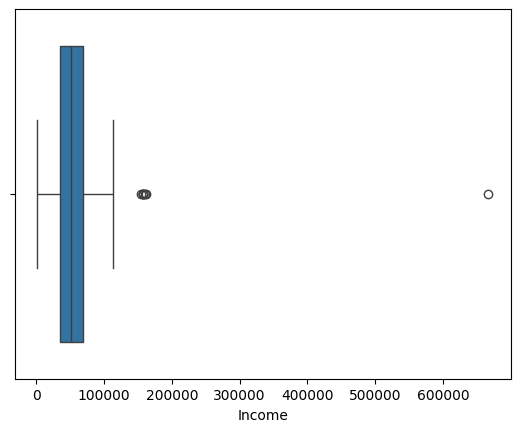

In [135]:
sns.boxplot(x=df['Income'])
plt.show() 

#### Income distribution contains extreme values as observed from the boxplot,therefore median imputation is more robust than mean imputation.

In [136]:
df['Income']= df['Income'].fillna(df['Income'].median()) # Handling the missing values by median imputation 

In [137]:
df.isnull().sum() # Verification about null values

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [138]:
df.duplicated().sum() #To check for duplicates

np.int64(0)

In [139]:
df.drop_duplicates(inplace=True) # There are no duplicates but just emphasising we must remove duplicate rows to maintain data integrity

In [140]:
df.duplicated().sum() # For verification

np.int64(0)

In [141]:
df.dtypes # To check data type of values in each column

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [142]:
df['Dt_Customer'].head() # To obtain first five rows of a particular column

0    04-09-2012
1    08-03-2014
2    21-08-2013
3    10-02-2014
4    19-01-2014
Name: Dt_Customer, dtype: str

In [143]:
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],format='%d-%m-%Y') # Conversion of the date column to datetime format

In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   str           
 3   Marital_Status       2240 non-null   str           
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[us]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-null   int64  

### Phase 3: Outlier Analysis

In [145]:
num_cols=df.select_dtypes(include=np.number).columns # Numerical columns
num_cols 

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact',
       'Z_Revenue', 'Response'],
      dtype='str')

In [146]:
df[num_cols].skew() # To determine skewness of each column

ID                      0.039832
Year_Birth             -0.349944
Income                  6.800947
Kidhome                 0.635288
Teenhome                0.407115
Recency                -0.001987
MntWines                1.175771
MntFruits               2.102063
MntMeatProducts         2.083233
MntFishProducts         1.919769
MntSweetProducts        2.136081
MntGoldProds            1.886106
NumDealsPurchases       2.418569
NumWebPurchases         1.382794
NumCatalogPurchases     1.880989
NumStorePurchases       0.702237
NumWebVisitsMonth       0.207926
AcceptedCmp3            3.291705
AcceptedCmp4            3.241574
AcceptedCmp5            3.291705
AcceptedCmp1            3.555444
AcceptedCmp2            8.472093
Complain               10.188972
Z_CostContact           0.000000
Z_Revenue               0.000000
Response                1.971555
dtype: float64

In [147]:
df[num_cols].skew().sort_values() # Arranging the columns based on their skewness

Year_Birth             -0.349944
Recency                -0.001987
Z_Revenue               0.000000
Z_CostContact           0.000000
ID                      0.039832
NumWebVisitsMonth       0.207926
Teenhome                0.407115
Kidhome                 0.635288
NumStorePurchases       0.702237
MntWines                1.175771
NumWebPurchases         1.382794
NumCatalogPurchases     1.880989
MntGoldProds            1.886106
MntFishProducts         1.919769
Response                1.971555
MntMeatProducts         2.083233
MntFruits               2.102063
MntSweetProducts        2.136081
NumDealsPurchases       2.418569
AcceptedCmp4            3.241574
AcceptedCmp3            3.291705
AcceptedCmp5            3.291705
AcceptedCmp1            3.555444
Income                  6.800947
AcceptedCmp2            8.472093
Complain               10.188972
dtype: float64

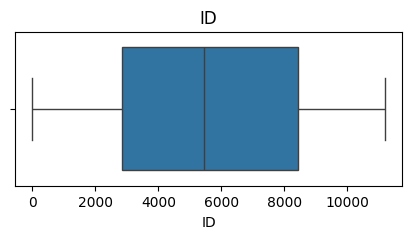

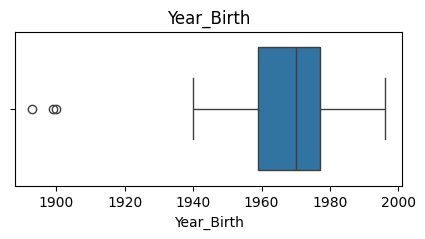

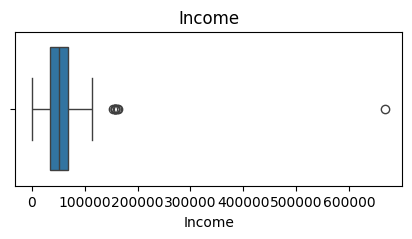

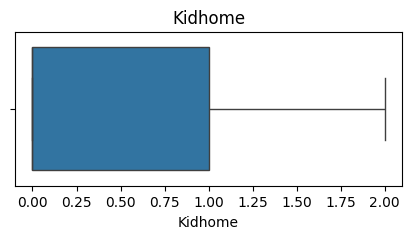

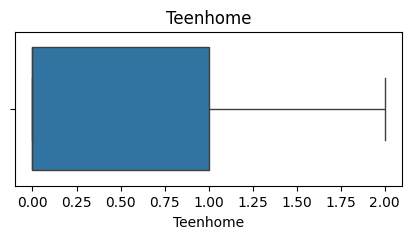

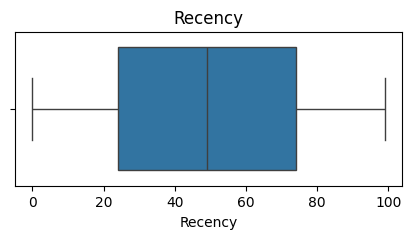

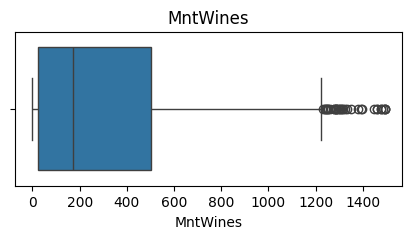

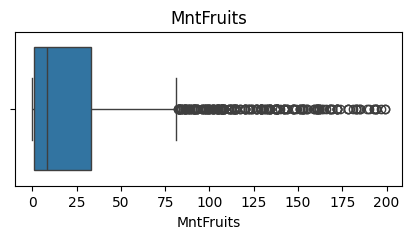

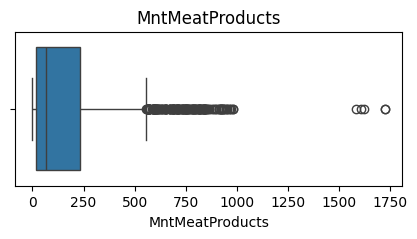

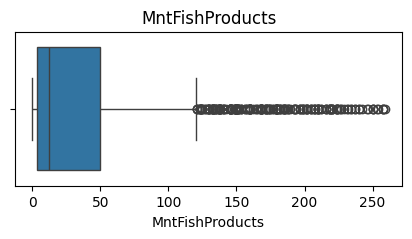

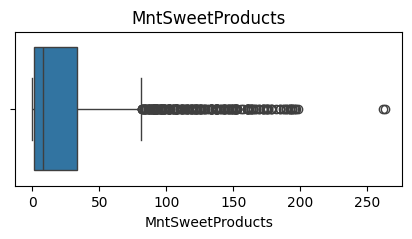

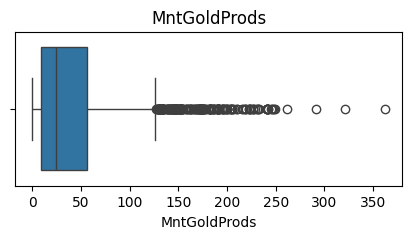

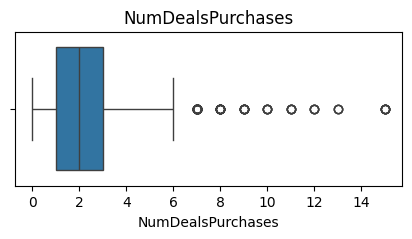

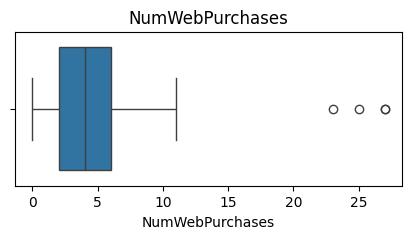

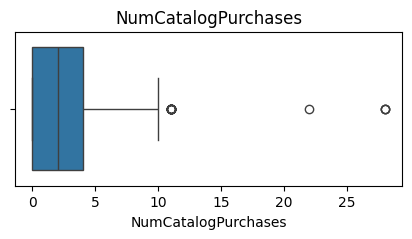

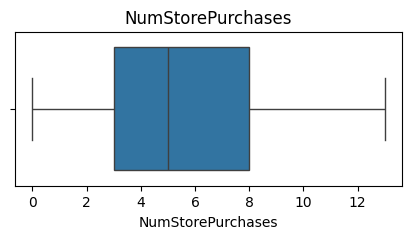

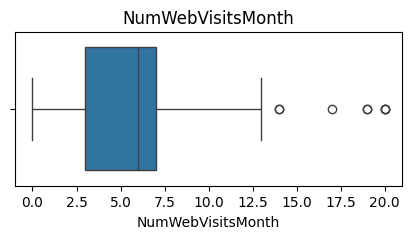

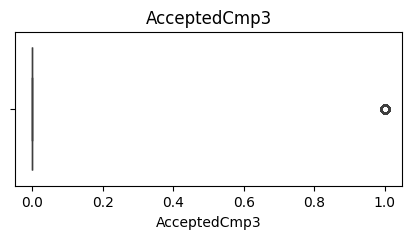

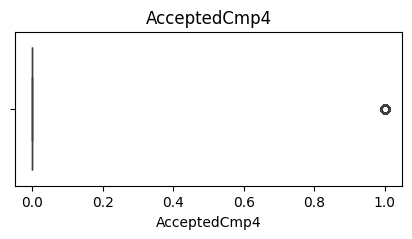

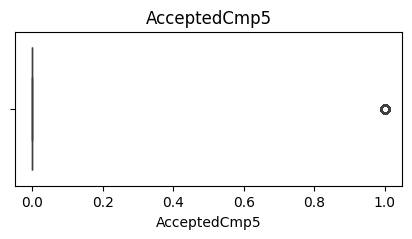

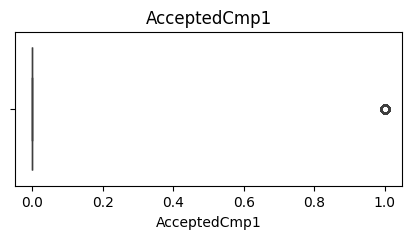

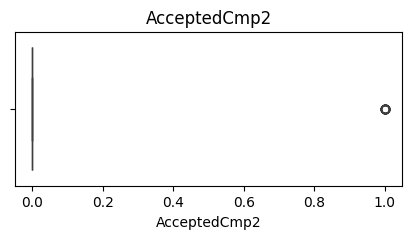

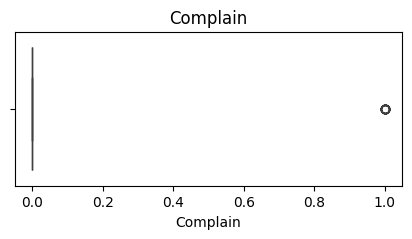

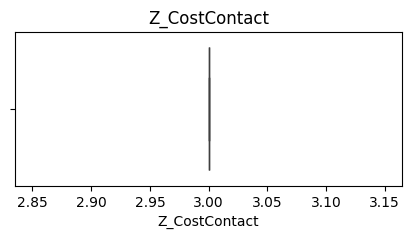

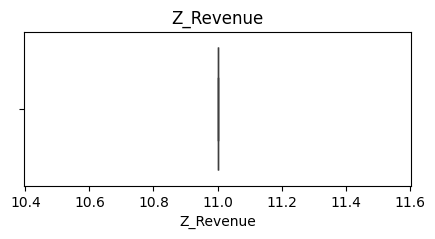

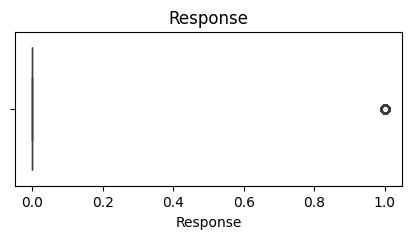

In [148]:
for col in num_cols:  # Boxplots of numerical columns
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [149]:
# Finding outliers using IQR(Interquartile Range) method

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col]<lower) | (df[col]>upper)]
    print(col,":", outliers.shape[0])

ID : 0
Year_Birth : 3
Income : 8
Kidhome : 0
Teenhome : 0
Recency : 0
MntWines : 35
MntFruits : 227
MntMeatProducts : 175
MntFishProducts : 223
MntSweetProducts : 248
MntGoldProds : 207
NumDealsPurchases : 86
NumWebPurchases : 4
NumCatalogPurchases : 23
NumStorePurchases : 0
NumWebVisitsMonth : 8
AcceptedCmp3 : 163
AcceptedCmp4 : 167
AcceptedCmp5 : 163
AcceptedCmp1 : 144
AcceptedCmp2 : 30
Complain : 21
Z_CostContact : 0
Z_Revenue : 0
Response : 334


In [150]:
# Handling outliers in each numerical column

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col] = np.where(df[col] > upper,upper,df[col])
    df[col] = np.where(df[col] < lower,lower,df[col])


#### Removing income outliers may remove valuable high-income customers. Hence, Winsorization(Capping) was used. Winsorization was applied to numerical variables to reduce the impact of extreme observations while preserving valuable customer records.

### Phase 4: Bivariate and Multivariate Exploration

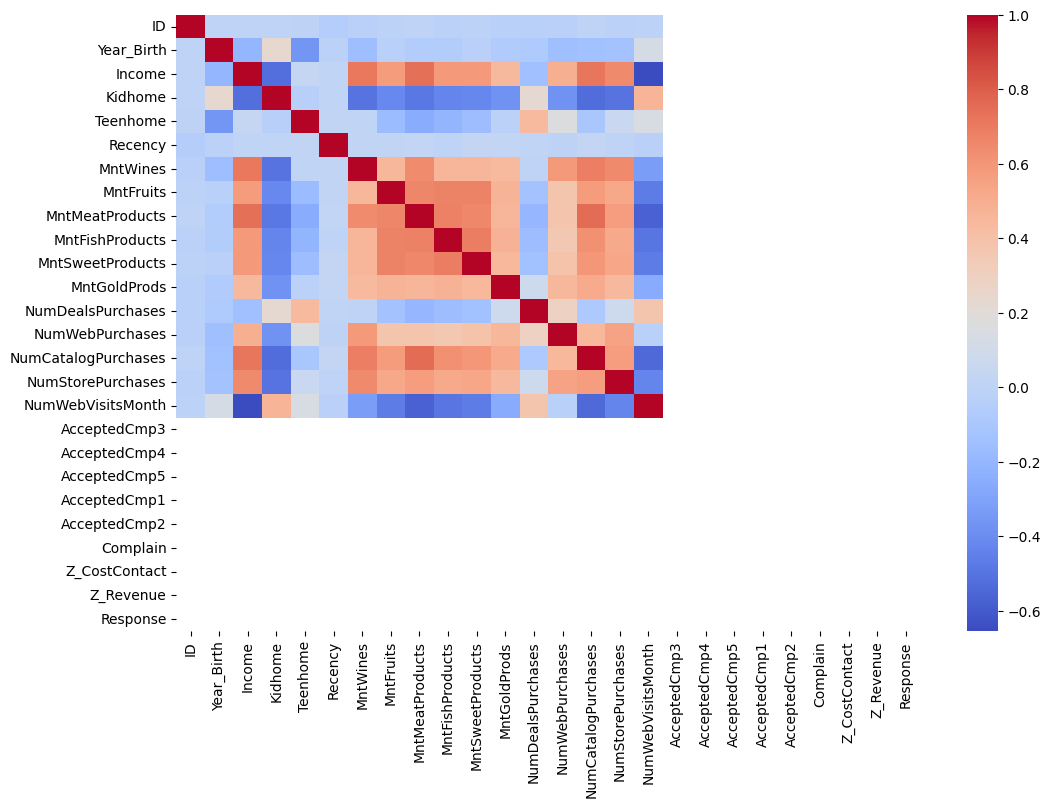

In [151]:
#Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(),cmap='coolwarm',annot=False)
plt.show()

In [152]:
df[num_cols].corr()['Income'].sort_values(ascending=False)

Income                 1.000000
MntMeatProducts        0.735959
NumCatalogPurchases    0.716688
MntWines               0.709656
NumStorePurchases      0.649785
MntSweetProducts       0.584574
MntFishProducts        0.580708
MntFruits              0.574504
NumWebPurchases        0.493046
MntGoldProds           0.441555
Teenhome               0.035890
Recency                0.005285
ID                     0.002103
NumDealsPurchases     -0.148294
Year_Birth            -0.204120
Kidhome               -0.519130
NumWebVisitsMonth     -0.653737
AcceptedCmp3                NaN
AcceptedCmp4                NaN
AcceptedCmp5                NaN
AcceptedCmp1                NaN
AcceptedCmp2                NaN
Complain                    NaN
Z_CostContact               NaN
Z_Revenue                   NaN
Response                    NaN
Name: Income, dtype: float64

#### Observations:

##### Correlations:

Strong Positive:

Income <-> Meat Spending

Income <-> Catalog Purchases

Income <-> Wine Spending

Negative:

Web Visits <-> Spending

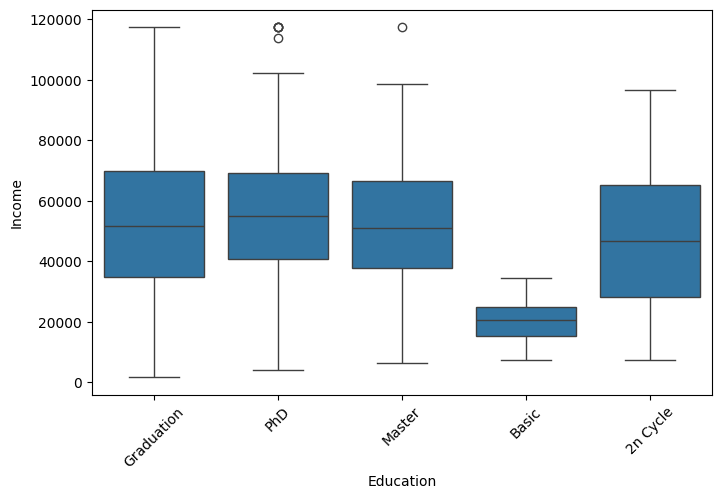

In [153]:
# Income vs Education
plt.figure(figsize=(8,5))
sns.boxplot(x='Education',y='Income',data=df)
plt.xticks(rotation=45)
plt.show()

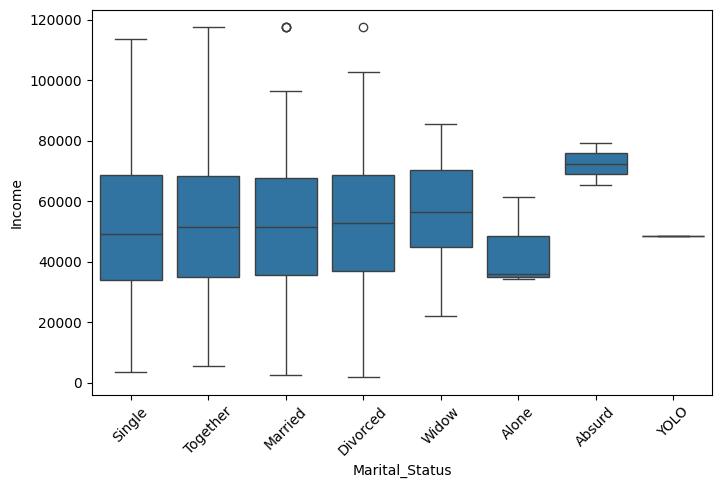

In [154]:
# Income vs Marital_Status
plt.figure(figsize=(8,5))
sns.boxplot(x='Marital_Status',y='Income',data=df)
plt.xticks(rotation=45)
plt.show()

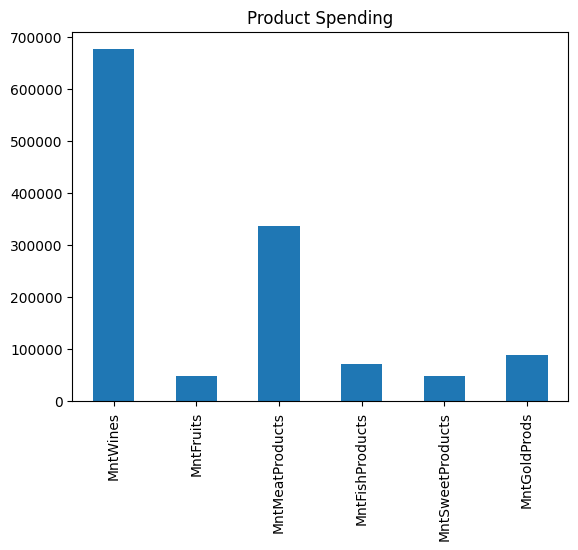

In [155]:
# Spending analysis
products = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
df[products].sum().plot(kind='bar')
plt.title("Product Spending")
plt.show()

In [ ]:
# Total Purchases vs Channel

channel_cols = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

df[channel_cols].sum().plot(kind='bar')

plt.title('Purchasing Channel Usage')
plt.ylabel('Total Purchases')
plt.xlabel('Channel')
plt.xticks(rotation=0)
plt.show()

#### Observations: 
##### Wines and Meat Products are spent more

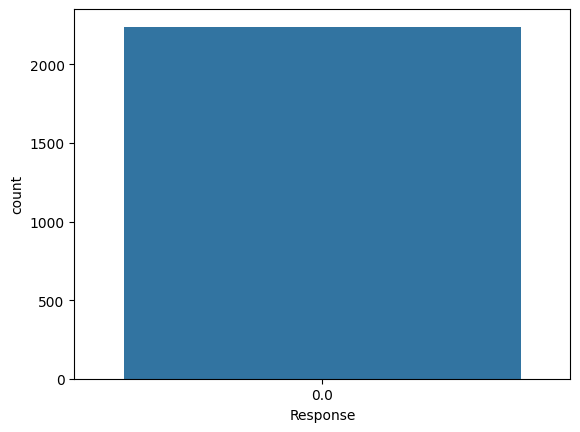

In [156]:
# Campaign Response Distribution

sns.countplot(x='Response',data=df)
plt.show()

##### Most customers did not accept the latest campaign, indicating potential opportunities to improve marketing strategies.

### correlation-vs-causation
#### Correlation does not imply causation. Although income and spending are strongly correlated, higher income does not directly cause spending. Other hidden factors such as lifestyle, preferences, and family size may influence spending behavior.

<Axes: xlabel='Income', ylabel='Count'>

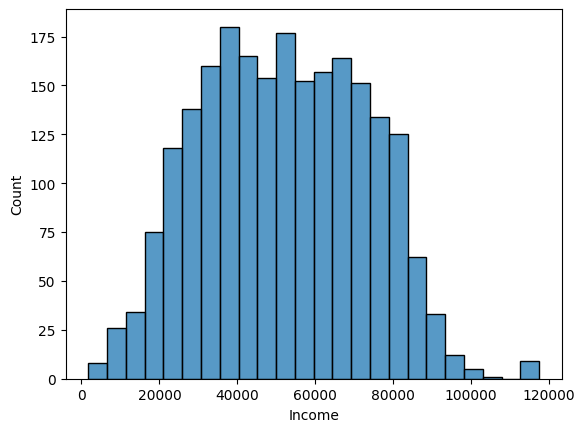

In [157]:
sns.histplot(df['Income'])

### Phase 5: Feature Engineering and Encoding

In [158]:
# Feature Engineering

# creating a new feature

df['Age'] = 2026 - df['Year_Birth'] #Creating 'Age'

In [159]:
df['Age']

0       69.0
1       72.0
2       61.0
3       42.0
4       45.0
        ... 
2235    59.0
2236    80.0
2237    45.0
2238    70.0
2239    72.0
Name: Age, Length: 2240, dtype: float64

In [160]:
df['Total_Children'] = (df['Kidhome']+ df['Teenhome']) # Creating 'Total_Children'

In [161]:
df['Total_Children']

0       0.0
1       2.0
2       0.0
3       1.0
4       1.0
       ... 
2235    1.0
2236    3.0
2237    0.0
2238    1.0
2239    2.0
Name: Total_Children, Length: 2240, dtype: float64

In [162]:
df['Total_Spending'] = (df['MntWines']+ df['MntFruits']+ df['MntMeatProducts']+ df['MntFishProducts']+ df['MntSweetProducts']
    + df['MntGoldProds']
)

In [163]:
df[['Total_Spending']].head()

,Total_Spending
0,1551.5
1,27.0
2,776.0
3,53.0
4,422.0


In [164]:
df.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending'],
      dtype='str')

In [165]:
df.shape #32 columns since 3 columns are added now

(2240, 32)

<Axes: xlabel='Age', ylabel='Count'>

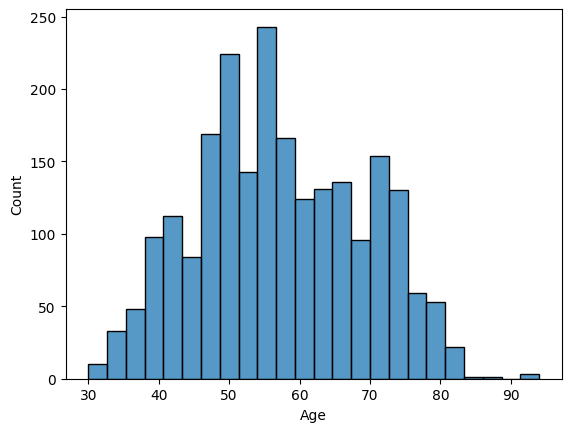

In [166]:
sns.histplot(df['Age'])

<Axes: xlabel='Income', ylabel='Total_Spending'>

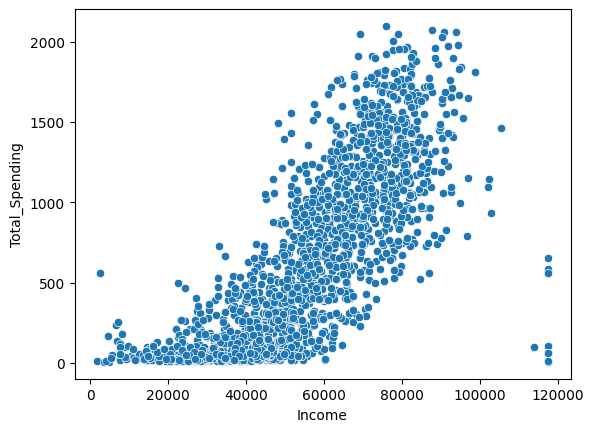

In [167]:
sns.scatterplot(x='Income', y='Total_Spending', data=df)

#### Ordinal and Nominal Variables :

##### Ordinal: Education
Ranking(Possible Order):

Basic

2n Cycle

Graduation

Master

PhD

##### Nominal: Marital_Status
No ranking exists.

In [168]:
# Label Encoding:

education_order = {'Basic':0,'2n Cycle':1,'Graduation':2,'Master':3,'PhD':4}
df['Education'] = df['Education'].map(education_order)

In [169]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending
0,5524.0,1957.0,2,Single,58138.0,0.0,0.0,2012-09-04,58.0,635.0,...,0.0,0.0,0.0,0.0,3.0,11.0,0.0,69.0,0.0,1551.5
1,2174.0,1954.0,2,Single,46344.0,1.0,1.0,2014-03-08,38.0,11.0,...,0.0,0.0,0.0,0.0,3.0,11.0,0.0,72.0,2.0,27.0
2,4141.0,1965.0,2,Together,71613.0,0.0,0.0,2013-08-21,26.0,426.0,...,0.0,0.0,0.0,0.0,3.0,11.0,0.0,61.0,0.0,776.0
3,6182.0,1984.0,2,Together,26646.0,1.0,0.0,2014-02-10,26.0,11.0,...,0.0,0.0,0.0,0.0,3.0,11.0,0.0,42.0,1.0,53.0
4,5324.0,1981.0,4,Married,58293.0,1.0,0.0,2014-01-19,94.0,173.0,...,0.0,0.0,0.0,0.0,3.0,11.0,0.0,45.0,1.0,422.0


In [170]:
df["Education"].head(20)

0     2
1     2
2     2
3     2
4     4
5     3
6     2
7     4
8     4
9     4
10    2
11    0
12    2
13    3
14    2
15    4
16    2
17    2
18    3
19    1
Name: Education, dtype: int64

In [171]:
# One Hot Encoding

df = pd.get_dummies(df,columns=['Marital_Status'],drop_first=True)

In [172]:
df.shape

(2240, 38)

In [ ]:
# Thus One-Hot Encoding increased the number of feature columns.

In [ ]:
df.columns

#### Final Dataset

In [ ]:
df.head()

In [ ]:
df.info()

### Conclusion:

####  Answer to business questions:

Q1. Customers with higher income spend more.
    
Q2. Wine products account for the highest customer spending.
    
Q3. Customers with fewer children tend to spend more.
    
Q4. People are more likely to purchase in stores rather than on web.

Q5. Customers with higher spending and income show greater campaign acceptance.

#### Key Findings:

 Education level influences purchasing behavior.

 Married and single customers show different spending patterns.

 Total_Spending is a useful engineered feature for future predictive modeling.